# Notebook 03a: Actual Features Inventory

## Purpose
This notebook provides a **comprehensive inventory** of features actually available in `features_engineered.pkl` after the extraction pipeline.

### Context
- **Raw extraction**: 1265 features per event
- **After correlation filtering** (threshold 0.95): 754 features
- Some physics features were filtered out due to correlation

---
**Date**: 2026-01-26  
**Data Source**: Latest pipeline run (4509 events)

In [1]:
# Imports
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

OUTPUT_DIR = Path('/sps/m4cast/_spiral2_data/_llrf_data/cooked_data')
print("Setup complete")

Setup complete


---
# 1. Load Data

In [2]:
# Load features
features_file = OUTPUT_DIR / 'features_engineered.pkl'
print(f"Loading: {features_file}")
print(f"File size: {features_file.stat().st_size / (1024**2):.1f} MB")

with open(features_file, 'rb') as f:
    data = pickle.load(f)

# Extract components
df_features = data['features_all']
feature_cols = data['feature_cols']  # Filtered features
X_scaled = data['X_scaled']
y_binary = data['y_binary']
signal_names = data['signal_names']

print(f"\n=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Events: {len(df_features):,}")
print(f"Features in df_features (raw): {len(df_features.columns):,}")
print(f"Features in feature_cols (filtered): {len(feature_cols):,}")
print(f"Signals: {len(signal_names)}")
print(f"Fault events: {y_binary.sum():,} ({100*y_binary.mean():.1f}%)")

Loading: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/features_engineered.pkl
File size: 80.8 MB

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
DATA SUMMARY
Events: 4,509
Features in df_features (raw): 1,265
Features in feature_cols (filtered): 754
Signals: 27
Fault events: 1,185 (26.3%)


---
# 2. Feature Categories

In [3]:
def categorize_features(feature_list):
    """Categorize features by type."""
    categories = defaultdict(list)
    
    # Physics features (specific names)
    physics_prefixes = [
        'effective_decay', 'decay_', 'detuning_', 'microphonics_',
        'forward_power', 'reflected_power', 'power_', 'rf_mismatch',
        'phase_jitter', 'phase_excursion', 'phase_noise', 'phase_psd',
        'phase_std_pre', 'phase_std_post', 'mod_',
        'rf_drive_on', 'llrf_loop', 'beam_present', 'interlock_type', 'valid_decay'
    ]
    
    for feat in feature_list:
        # Check physics first
        is_physics = any(feat.startswith(p) or feat == p.rstrip('_') for p in physics_prefixes)
        
        if is_physics:
            # Sub-categorize physics
            if 'decay' in feat:
                categories['Physics: Effective Decay'].append(feat)
            elif 'detun' in feat:
                categories['Physics: Detuning'].append(feat)
            elif 'micro' in feat:
                categories['Physics: Microphonics'].append(feat)
            elif 'power' in feat or 'forward' in feat or 'reflected' in feat:
                categories['Physics: RF Power'].append(feat)
            elif 'mismatch' in feat:
                categories['Physics: RF Mismatch'].append(feat)
            elif 'phase_jitter' in feat or 'phase_excursion' in feat or 'phase_noise' in feat or 'phase_psd' in feat:
                categories['Physics: Phase Stability'].append(feat)
            elif 'phase_std' in feat or 'mod_' in feat:
                categories['Physics: Control Loop'].append(feat)
            elif any(x in feat for x in ['rf_drive', 'llrf_loop', 'beam_present', 'interlock', 'valid_decay']):
                categories['Physics: Validity Flags'].append(feat)
            else:
                categories['Physics: Other'].append(feat)
        else:
            # Statistical features by signal
            found_signal = False
            for sig in signal_names:
                if feat.startswith(sig + '_'):
                    categories[f'Statistical: {sig}'].append(feat)
                    found_signal = True
                    break
            
            if not found_signal:
                categories['Other'].append(feat)
    
    return dict(categories)

# Categorize filtered features
categories = categorize_features(feature_cols)

print("=" * 60)
print("FEATURE CATEGORIES (Filtered - in final model)")
print("=" * 60)
for cat, feats in sorted(categories.items()):
    print(f"\n{cat}: {len(feats)} features")

FEATURE CATEGORIES (Filtered - in final model)

Other: 8 features

Physics: Control Loop: 7 features

Physics: Detuning: 5 features

Physics: Effective Decay: 5 features

Physics: Microphonics: 2 features

Physics: RF Mismatch: 4 features

Physics: RF Power: 4 features

Physics: Validity Flags: 4 features

Statistical: A Uamp: 28 features

Statistical: A Uamp binary: 30 features

Statistical: A Ucr: 31 features

Statistical: A Ucr binary: 29 features

Statistical: DPCI: 27 features

Statistical: I Fref binary: 25 features

Statistical: I Ucav binary: 33 features

Statistical: I Uci binary: 31 features

Statistical: I modulateur: 1 features

Statistical: I modulateur binary: 30 features

Statistical: IQ: 29 features

Statistical: MODP: 27 features

Statistical: PhaseCav: 31 features

Statistical: PhaseUci: 32 features

Statistical: Q Fref binary: 26 features

Statistical: Q Ucav binary: 30 features

Statistical: Q Uci binary: 32 features

Statistical: Q modulateur: 1 features

Statistic

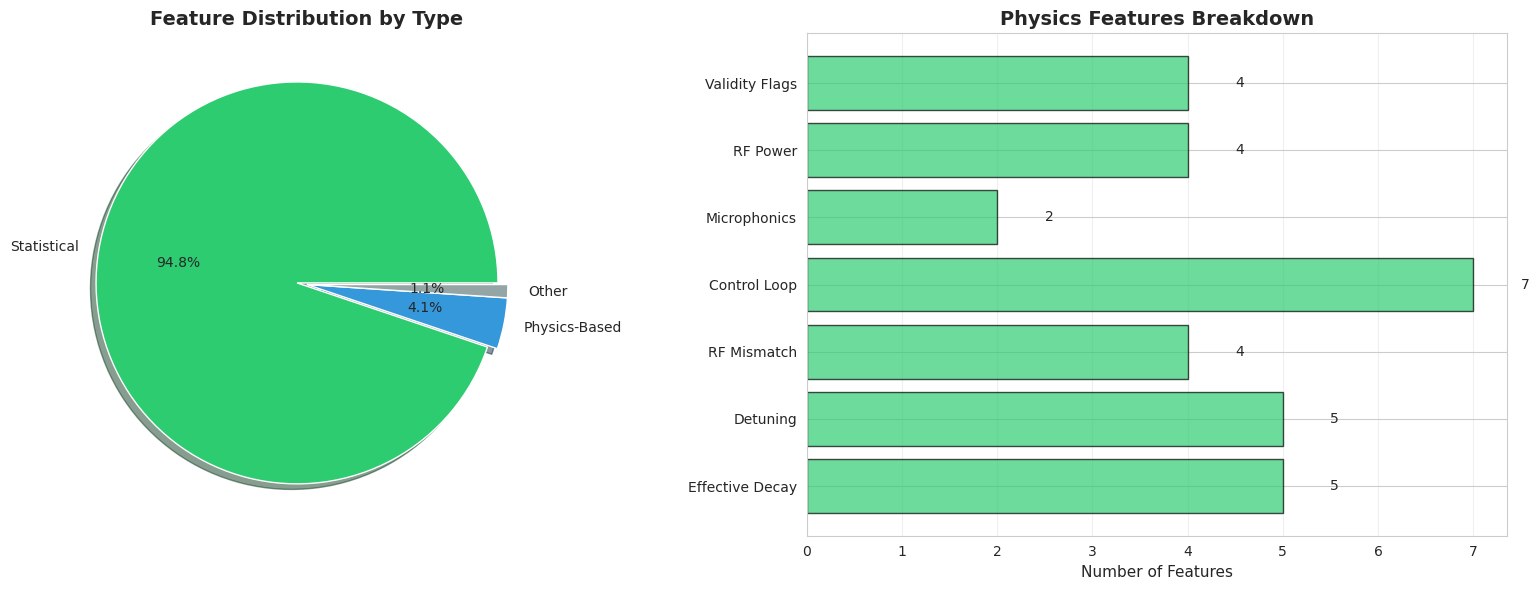


Total Physics Features: 31
Total Statistical Features: 715


In [4]:
# Visualization of category distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aggregate categories
agg_cats = defaultdict(int)
for cat, feats in categories.items():
    if cat.startswith('Physics'):
        agg_cats['Physics-Based'] += len(feats)
    elif cat.startswith('Statistical'):
        agg_cats['Statistical'] += len(feats)
    else:
        agg_cats['Other'] += len(feats)

# Pie chart
colors = ['#2ecc71', '#3498db', '#95a5a6']
axes[0].pie(agg_cats.values(), labels=agg_cats.keys(), autopct='%1.1f%%',
            colors=colors, explode=[0.05, 0, 0], shadow=True)
axes[0].set_title('Feature Distribution by Type', fontweight='bold', fontsize=14)

# Bar chart of physics subcategories
physics_cats = {k: len(v) for k, v in categories.items() if k.startswith('Physics')}
if physics_cats:
    cats = [k.replace('Physics: ', '') for k in physics_cats.keys()]
    vals = list(physics_cats.values())
    bars = axes[1].barh(cats, vals, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Number of Features', fontsize=11)
    axes[1].set_title('Physics Features Breakdown', fontweight='bold', fontsize=14)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, val in zip(bars, vals):
        axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                    str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTotal Physics Features: {agg_cats.get('Physics-Based', 0)}")
print(f"Total Statistical Features: {agg_cats.get('Statistical', 0)}")

---
# 3. Physics Features Detail

In [5]:
# List all physics features with their statistics
print("=" * 80)
print("PHYSICS FEATURES AVAILABLE (in filtered feature set)")
print("=" * 80)

for cat in sorted([k for k in categories.keys() if k.startswith('Physics')]):
    print(f"\n{'='*40}")
    print(f"{cat}")
    print(f"{'='*40}")
    
    for feat in sorted(categories[cat]):
        if feat in feature_cols:
            idx = feature_cols.index(feat)
            vals = X_scaled[:, idx]
            print(f"  {feat}")
            print(f"    Range: [{vals.min():.3f}, {vals.max():.3f}]")
            print(f"    Mean: {vals.mean():.3f}, Std: {vals.std():.3f}")

PHYSICS FEATURES AVAILABLE (in filtered feature set)

Physics: Control Loop
  mod_amplitude_max_post
    Range: [-1.205, 6.203]
    Mean: 0.000, Std: 1.000
  mod_amplitude_mean_pre
    Range: [-33.556, 23.637]
    Mean: 0.000, Std: 1.000
  mod_amplitude_std_pre
    Range: [-1.372, 11.828]
    Mean: 0.000, Std: 1.000
  mod_phase_change
    Range: [-34.519, 30.594]
    Mean: 0.000, Std: 1.000
  mod_phase_std_pre
    Range: [-1.243, 12.876]
    Mean: -0.000, Std: 1.000
  phase_std_post
    Range: [-1.333, 0.880]
    Mean: 0.000, Std: 1.000
  phase_std_pre
    Range: [-0.720, 4.575]
    Mean: -0.000, Std: 1.000

Physics: Detuning
  detuning_jump_at_trigger
    Range: [-3.781, 3.917]
    Mean: -0.000, Std: 1.000
  detuning_mean_hz
    Range: [-20.692, 38.766]
    Mean: -0.000, Std: 1.000
  detuning_peak_to_peak
    Range: [-1.104, 15.330]
    Mean: -0.000, Std: 1.000
  detuning_slope_hz_s
    Range: [-3.849, 5.791]
    Mean: -0.000, Std: 1.000
  detuning_std_hz
    Range: [-1.020, 8.510]
  

---
# 4. Expected vs Actual Features Comparison

In [6]:
# Features expected by notebook 03_feature_exploration_updated.ipynb
expected_features = {
    'Effective Decay': [
        'effective_decay_tau', 'decay_rate', 'decay_fit_r2', 
        'decay_relative_to_nominal', 'decay_non_exponentiality'
    ],
    'Detuning': [
        'detuning_mean_hz', 'detuning_std_hz', 'detuning_slope_hz_s',
        'detuning_peak_to_peak', 'detuning_jump_at_trigger'
    ],
    'Microphonics': [
        'microphonics_rms', 'microphonics_dom_freq',
        'microphonics_band_power_10_100', 'microphonics_q_factor'
    ],
    'Control Loop': [
        'amp_rms_pre', 'amp_rms_post', 'phase_rms_pre', 'phase_rms_post',
        'control_overshoot_amp', 'control_settling_time', 'control_saturation_fraction'
    ],
    'Phase Stability': [
        'phase_jitter_rms', 'phase_excursion_pp', 
        'phase_noise_slope', 'phase_psd_integral'
    ],
    'RF Power Flow': [
        'forward_power_mean', 'reflected_power_mean', 'power_reflection_ratio',
        'power_jump_at_trigger', 'power_imbalance_rms'
    ],
    'Validity Flags': [
        'rf_drive_on', 'llrf_loop_closed', 'beam_present', 
        'interlock_type', 'valid_decay_window'
    ]
}

# Check raw df_features (before filtering)
raw_cols = set(df_features.columns)
filtered_cols = set(feature_cols)

print("=" * 80)
print("EXPECTED vs ACTUAL FEATURES COMPARISON")
print("=" * 80)

summary = []
for category, feats in expected_features.items():
    print(f"\n{category}:")
    print("-" * 40)
    
    for feat in feats:
        in_raw = feat in raw_cols
        in_filtered = feat in filtered_cols
        
        if in_filtered:
            status = "AVAILABLE"
            icon = "\u2713"
        elif in_raw:
            status = "FILTERED OUT (correlation)"
            icon = "\u26A0"
        else:
            status = "NOT EXTRACTED"
            icon = "\u2717"
        
        print(f"  {icon} {feat}: {status}")
        summary.append({'Category': category, 'Feature': feat, 'Status': status})

df_summary = pd.DataFrame(summary)

EXPECTED vs ACTUAL FEATURES COMPARISON

Effective Decay:
----------------------------------------
  ✓ effective_decay_tau: AVAILABLE
  ✓ decay_rate: AVAILABLE
  ✓ decay_fit_r2: AVAILABLE
  ⚠ decay_relative_to_nominal: FILTERED OUT (correlation)
  ✓ decay_non_exponentiality: AVAILABLE

Detuning:
----------------------------------------
  ✓ detuning_mean_hz: AVAILABLE
  ✓ detuning_std_hz: AVAILABLE
  ✓ detuning_slope_hz_s: AVAILABLE
  ✓ detuning_peak_to_peak: AVAILABLE
  ✓ detuning_jump_at_trigger: AVAILABLE

Microphonics:
----------------------------------------
  ⚠ microphonics_rms: FILTERED OUT (correlation)
  ✓ microphonics_dom_freq: AVAILABLE
  ✓ microphonics_band_power_10_100: AVAILABLE
  ⚠ microphonics_q_factor: FILTERED OUT (correlation)

Control Loop:
----------------------------------------
  ✗ amp_rms_pre: NOT EXTRACTED
  ✗ amp_rms_post: NOT EXTRACTED
  ✗ phase_rms_pre: NOT EXTRACTED
  ✗ phase_rms_post: NOT EXTRACTED
  ✗ control_overshoot_amp: NOT EXTRACTED
  ✗ control_settlin

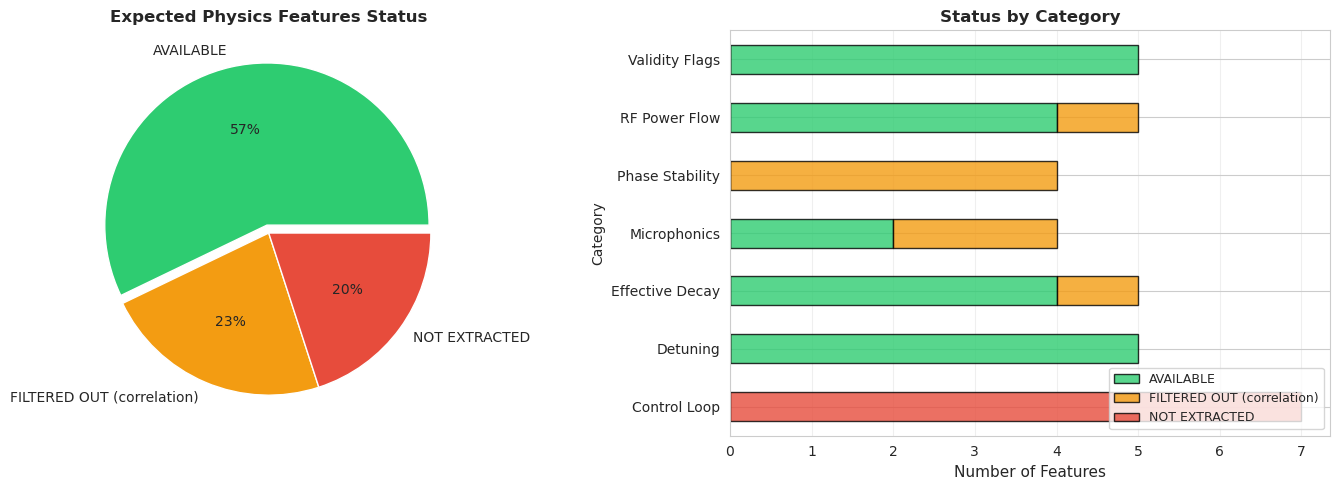


Summary:
  AVAILABLE: 20 features
  FILTERED OUT (correlation): 8 features
  NOT EXTRACTED: 7 features


In [7]:
# Summary visualization
status_counts = df_summary['Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall status
colors_status = {'AVAILABLE': '#2ecc71', 'FILTERED OUT (correlation)': '#f39c12', 'NOT EXTRACTED': '#e74c3c'}
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.0f%%',
            colors=[colors_status.get(s, 'gray') for s in status_counts.index],
            explode=[0.05 if s == 'AVAILABLE' else 0 for s in status_counts.index])
axes[0].set_title('Expected Physics Features Status', fontweight='bold', fontsize=12)

# By category
category_status = df_summary.groupby(['Category', 'Status']).size().unstack(fill_value=0)
category_status.plot(kind='barh', stacked=True, ax=axes[1],
                     color=[colors_status.get(c, 'gray') for c in category_status.columns],
                     edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_title('Status by Category', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nSummary:")
for status, count in status_counts.items():
    print(f"  {status}: {count} features")

---
# 5. Alternative Features Available

Some expected features have alternatives with different names.

In [8]:
# Map expected features to available alternatives
alternatives = {
    'amp_rms_pre': 'rf_mismatch_rms_pre',
    'amp_rms_post': 'rf_mismatch_rms_post',
    'phase_rms_pre': 'phase_std_pre',
    'phase_rms_post': 'phase_std_post',
    'control_settling_time': 'rf_mismatch_settling_time',
    'control_saturation_fraction': 'reflected_saturation_fraction',
}

print("=" * 80)
print("ALTERNATIVE FEATURES AVAILABLE")
print("=" * 80)
print("\nSome expected features have equivalents with different names:\n")

for expected, alternative in alternatives.items():
    in_raw = alternative in raw_cols
    in_filtered = alternative in filtered_cols
    
    if in_filtered:
        status = "AVAILABLE"
        icon = "\u2713"
    elif in_raw:
        status = "IN RAW (filtered out)"
        icon = "\u26A0"
    else:
        status = "NOT FOUND"
        icon = "\u2717"
    
    print(f"  {expected}")
    print(f"    -> {alternative}: {icon} {status}")
    print()

ALTERNATIVE FEATURES AVAILABLE

Some expected features have equivalents with different names:

  amp_rms_pre
    -> rf_mismatch_rms_pre: ✓ AVAILABLE

  amp_rms_post
    -> rf_mismatch_rms_post: ✓ AVAILABLE

  phase_rms_pre
    -> phase_std_pre: ✓ AVAILABLE

  phase_rms_post
    -> phase_std_post: ✓ AVAILABLE

  control_settling_time
    -> rf_mismatch_settling_time: ✓ AVAILABLE

  control_saturation_fraction
    -> reflected_saturation_fraction: ✓ AVAILABLE



---
# 6. Features in Raw Batch vs Final

In [9]:
# Load a batch file to compare
batch_dir = OUTPUT_DIR / 'batches'
batch_files = sorted(batch_dir.glob('batch_*.pkl'))

if batch_files:
    with open(batch_files[0], 'rb') as f:
        batch_data = pickle.load(f)
    
    results = batch_data['results']
    if results:
        raw_batch_features = set(results[0]['features'].keys())
        
        # Features in batch but not in final
        dropped_by_filter = raw_batch_features - filtered_cols
        
        print("=" * 80)
        print("FEATURES DROPPED BY CORRELATION FILTER")
        print("=" * 80)
        print(f"\nTotal in raw batch: {len(raw_batch_features)}")
        print(f"Total in final: {len(filtered_cols)}")
        print(f"Dropped: {len(dropped_by_filter)}")
        
        # Physics features that were dropped
        physics_keywords = ['decay', 'detun', 'micro', 'power', 'phase_jitter', 
                          'phase_excursion', 'phase_noise', 'phase_psd', 'mismatch']
        dropped_physics = [f for f in dropped_by_filter 
                          if any(kw in f.lower() for kw in physics_keywords)]
        
        print(f"\nPhysics features dropped ({len(dropped_physics)}):")
        for f in sorted(dropped_physics):
            print(f"  - {f}")
else:
    print("No batch files found")

FEATURES DROPPED BY CORRELATION FILTER

Total in raw batch: 1265
Total in final: 754
Dropped: 511

Physics features dropped (8):
  - decay_relative_to_nominal
  - microphonics_q_factor
  - microphonics_rms
  - phase_excursion_pp
  - phase_jitter_rms
  - phase_noise_slope
  - phase_psd_integral
  - power_reflection_ratio


---
# 7. Statistical Features by Signal

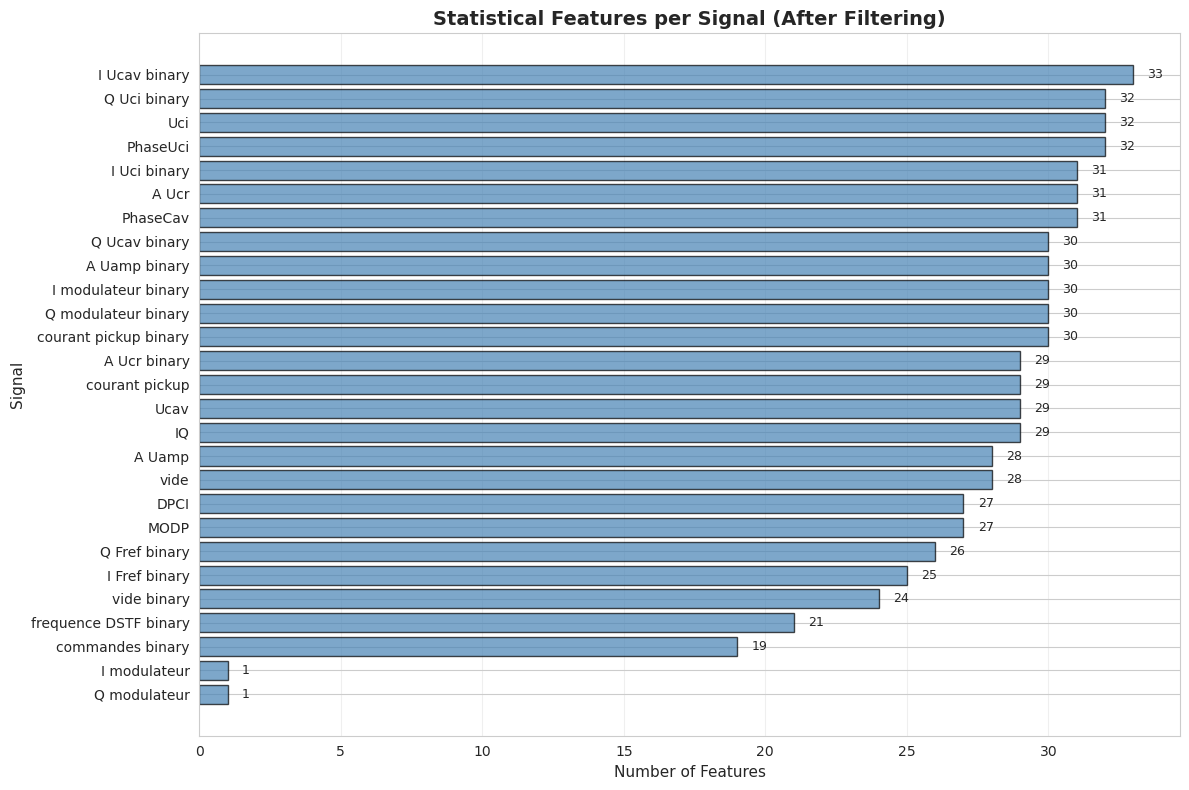


Total statistical features: 715
Average per signal: 26.5


In [10]:
# Count features per signal
signal_feature_counts = {}
for sig in signal_names:
    count = sum(1 for f in feature_cols if f.startswith(sig + '_'))
    signal_feature_counts[sig] = count

# Sort by count
sorted_signals = sorted(signal_feature_counts.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(12, 8))
signals = [s[0] for s in sorted_signals]
counts = [s[1] for s in sorted_signals]

bars = ax.barh(signals, counts, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('Signal', fontsize=11)
ax.set_title('Statistical Features per Signal (After Filtering)', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, counts):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTotal statistical features: {sum(counts)}")
print(f"Average per signal: {sum(counts)/len(signal_names):.1f}")

---
# 8. Feature Types Available per Signal

In [11]:
# Extract feature types (suffixes)
feature_types = set()
for f in feature_cols:
    for sig in signal_names:
        if f.startswith(sig + '_'):
            suffix = f[len(sig)+1:]
            feature_types.add(suffix)
            break

print("=" * 60)
print(f"STATISTICAL FEATURE TYPES AVAILABLE ({len(feature_types)} types)")
print("=" * 60)

# Group by category
type_categories = {
    'Basic Stats': ['mean', 'std', 'min', 'max', 'range', 'median'],
    'Percentiles': ['q1', 'q3', 'iqr'],
    'Shape': ['skewness', 'kurtosis'],
    'Energy': ['rms', 'energy', 'crest_factor'],
    'Events': ['peak_count', 'n_zero_crossings'],
    'Correlation': ['autocorr_lag1'],
    'Temporal': ['trend_slope', 'early_late_diff', 'early_late_ratio', 'var_ratio_late_early'],
    'Segments': [t for t in feature_types if 'segment' in t],
    'Dynamics': ['velocity_mean', 'velocity_max', 'accel_mean', 'accel_max', 'cusum_max']
}

for cat, types in type_categories.items():
    available = [t for t in types if t in feature_types]
    if available:
        print(f"\n{cat}:")
        for t in available:
            print(f"  - {t}")

STATISTICAL FEATURE TYPES AVAILABLE (39 types)

Basic Stats:
  - mean
  - std
  - min
  - max
  - range
  - median

Percentiles:
  - q1
  - q3
  - iqr

Shape:
  - skewness
  - kurtosis

Energy:
  - energy

Events:
  - peak_count
  - n_zero_crossings

Correlation:
  - autocorr_lag1

Temporal:
  - trend_slope
  - early_late_diff
  - early_late_ratio
  - var_ratio_late_early

Segments:
  - segment_mid_late_slope
  - segment_mid_std
  - segment_late_slope
  - segment_mid_mean
  - segment_mid_late_std
  - segment_mid_early_slope
  - segment_mid_early_mean
  - segment_early_mean
  - segment_late_mean
  - segment_mid_late_mean
  - segment_mid_slope
  - segment_mid_early_std
  - segment_late_std

Dynamics:
  - velocity_mean
  - velocity_max
  - accel_mean
  - accel_max
  - cusum_max


---
# 9. Summary & Recommendations

In [12]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)

# Count available physics features
physics_available = sum(len(v) for k, v in categories.items() if k.startswith('Physics'))
stats_available = sum(len(v) for k, v in categories.items() if k.startswith('Statistical'))

print(f"\nFeatures available for modeling:")
print(f"  Total: {len(feature_cols)}")
print(f"  Physics-based: {physics_available}")
print(f"  Statistical: {stats_available}")

print(f"\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

print("""
1. CORRELATION FILTERING:
   - 8 physics features were extracted but filtered out
   - Consider protecting physics features from correlation filter
   - Or lower threshold from 0.95 to 0.98

2. MISSING CONTROL LOOP FEATURES:
   - Use existing alternatives:
     * rf_mismatch_rms_pre/post instead of amp_rms_pre/post
     * phase_std_pre/post instead of phase_rms_pre/post
     * rf_mismatch_settling_time instead of control_settling_time
     * reflected_saturation_fraction instead of control_saturation_fraction

3. UPDATE NOTEBOOKS:
   - Update 03_feature_exploration_updated.ipynb to use actual feature names
   - Or modify extraction script to add expected feature names as aliases
""")

SUMMARY

Features available for modeling:
  Total: 754
  Physics-based: 31
  Statistical: 715

RECOMMENDATIONS

1. CORRELATION FILTERING:
   - 8 physics features were extracted but filtered out
   - Consider protecting physics features from correlation filter
   - Or lower threshold from 0.95 to 0.98

2. MISSING CONTROL LOOP FEATURES:
   - Use existing alternatives:
     * rf_mismatch_rms_pre/post instead of amp_rms_pre/post
     * phase_std_pre/post instead of phase_rms_pre/post
     * rf_mismatch_settling_time instead of control_settling_time
     * reflected_saturation_fraction instead of control_saturation_fraction

3. UPDATE NOTEBOOKS:
   - Update 03_feature_exploration_updated.ipynb to use actual feature names
   - Or modify extraction script to add expected feature names as aliases



In [13]:
# Export feature inventory
inventory = {
    'all_features': feature_cols,
    'categories': dict(categories),
    'signal_names': signal_names,
    'expected_vs_actual': df_summary.to_dict('records'),
    'alternatives': alternatives
}

inventory_file = OUTPUT_DIR / 'feature_inventory.pkl'
with open(inventory_file, 'wb') as f:
    pickle.dump(inventory, f)

print(f"Saved feature inventory to: {inventory_file}")

Saved feature inventory to: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/feature_inventory.pkl


---
**Notebook Complete**